# 01 - Where is the missing performance?

`experiments/01_bound.ipynb` showed that an oracle knowing the exact node state
could reach `AP = 0.902` on this test set, while the best model measured `0.1253`.
That leaves roughly seven eighths of the distance to a perfect classifier
unaccounted for, and **co-tenancy is not the cause** - it explains only 13 % of it.

Three things could account for the rest:

* **capacity** - the features determine the label but the model is too small to say so
* **variance** - the model learns the training data but it does not transfer
* **signal** - the features simply do not determine the label

These call for completely different responses, so guessing between them would be a
waste. This notebook separates them with three measurements.

## What each measurement means

**A capacity ladder.** Fit progressively larger models. If test `AP` climbs with
capacity, we are capacity-limited and should keep growing. If it flattens while
*train* `AP` keeps climbing, we are variance-limited. If neither moves, the features
are the problem.

**A label-permutation control.** Train `AP` alone proves nothing: with 56 continuous
features almost every row is unique, so a large enough tree ensemble can memorise
*any* labelling, including a random one. The permuted-label run at matched capacity
is what makes the train numbers interpretable - it shows what pure memorisation
looks like, so real-label performance can be read against it.

**A learning curve over jobs.** Session 3 found the curve still rising at stride 5.
If test `AP` is still climbing with training volume, more data is a live lever;
if it has flattened, it is not.

## Pre-registration

**D1.** If we were capacity-limited, test `AP` would rise materially across the
ladder. Prediction: it will **not** - session 3 already found that expanding the
metric set (8 -> 36 metrics, +0.059 AP) bought nearly the entire gain while deeper
trees *hurt*. So the expected result is a flat test curve with a widening train-test
gap.

**D2.** The permuted-label control will reach high **train** AP and chance-level
**test** AP, confirming the ladder can memorise and therefore that a flat test curve
is not an artefact of insufficient capacity.

**D3.** The learning curve will still be rising at 100 % of the data.

If D1 holds, growing the model is pointless and the productive lever is **better
features** - which is what `02` then tests.

In [1]:
# -- Setup ---------------------------------------------------------------------
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
EDA  = ROOT / "04_eda" / "data"
DATA, FIGS = Path("data"), Path("figures")
DATA.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

BASE = dict(objective="binary", verbose=-1, n_jobs=-1, random_state=0)

# The ladder. Each rung is strictly larger than the one before it; the last rung
# removes the regularisation that would stop it memorising.
LADDER = [
    ("A  reference",  dict(n_estimators=300,  num_leaves=31,  learning_rate=0.05)),
    ("B  larger",     dict(n_estimators=600,  num_leaves=63,  learning_rate=0.05)),
    ("C  large",      dict(n_estimators=1000, num_leaves=127, learning_rate=0.05)),
    ("D  saturated",  dict(n_estimators=800,  num_leaves=255, learning_rate=0.10,
                           min_child_samples=1, reg_alpha=0.0, reg_lambda=0.0,
                           colsample_bytree=1.0, subsample=1.0)),
]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

def save(fig, name):
    fig.savefig(FIGS / name, bbox_inches="tight"); return fig

facts = {}
t0 = time.time()
print("setup ok")

setup ok


## Step 1 - Data

The 56-column `eda/` feature set and the temporal split already stored in the file.
Absolute numbers are therefore lower than `pipeline_v2`'s 144-column result by
construction; what matters here is the *shape* of the curves, which is a property of
the feature set rather than of its size.

In [2]:
w = pd.read_parquet(EDA / "windows.parquet")
FEATURES = [c for c in w.columns if "__" in c]
tr, te = w[w.split == "train"], w[w.split == "test"]
Xtr, ytr = tr[FEATURES], tr.y.to_numpy()
Xte, yte = te[FEATURES], te.y.to_numpy()
BASE_RATE_TR, BASE_RATE_TE = ytr.mean(), yte.mean()

print(f"train {len(tr):,} windows / {tr.slurm_id.nunique():,} jobs   "
      f"positive rate {100*BASE_RATE_TR:.2f} %")
print(f"test  {len(te):,} windows / {te.slurm_id.nunique():,} jobs   "
      f"positive rate {100*BASE_RATE_TE:.2f} %")
print(f"features {len(FEATURES)}")

train 915,508 windows / 10,265 jobs   positive rate 3.26 %
test  142,309 windows / 2,694 jobs   positive rate 4.09 %
features 56


## Step 2 - The capacity ladder

For each rung: train `AP`, test `AP`, and the ratio between them. A model that is
capacity-limited shows both numbers rising together. A model that is
variance-limited shows train rising and test flat.

In [3]:
rows, models = [], {}
for name, cfg in LADDER:
    m = lgb.LGBMClassifier(**BASE, **cfg).fit(Xtr, ytr)
    ap_tr = average_precision_score(ytr, m.predict_proba(Xtr)[:, 1])
    ap_te = average_precision_score(yte, m.predict_proba(Xte)[:, 1])
    models[name] = m
    rows.append(dict(rung=name, rounds=cfg["n_estimators"], leaves=cfg["num_leaves"],
                     train_ap=ap_tr, test_ap=ap_te,
                     train_lift=ap_tr / BASE_RATE_TR, test_lift=ap_te / BASE_RATE_TE,
                     gap=ap_tr / ap_te))
    print(f"{name:14s} rounds {cfg['n_estimators']:5d} leaves {cfg['num_leaves']:4d}   "
          f"train AP {ap_tr:.4f}   test AP {ap_te:.4f}   "
          f"gap {ap_tr/ap_te:5.1f}x   [{time.time()-t0:.0f}s]")

ladder = pd.DataFrame(rows)
ladder.to_csv(DATA / "capacity_ladder.csv", index=False)
print()
print(ladder.round(4).to_string(index=False))

A  reference   rounds   300 leaves   31   train AP 0.5782   test AP 0.0797   gap   7.3x   [14s]


B  larger      rounds   600 leaves   63   train AP 0.7903   test AP 0.0795   gap   9.9x   [41s]


C  large       rounds  1000 leaves  127   train AP 0.9265   test AP 0.0852   gap  10.9x   [94s]


D  saturated   rounds   800 leaves  255   train AP 0.9950   test AP 0.0655   gap  15.2x   [145s]

        rung  rounds  leaves  train_ap  test_ap  train_lift  test_lift     gap
A  reference     300      31    0.5782   0.0797     17.7396     1.9471  7.2534
   B  larger     600      63    0.7903   0.0795     24.2475     1.9425  9.9378
    C  large    1000     127    0.9265   0.0852     28.4255     2.0805 10.8772
D  saturated     800     255    0.9950   0.0655     30.5297     1.5991 15.1995


## Step 3 - The permutation control

The same saturated configuration, trained on **shuffled labels**. The shuffle is
done at the level of whole jobs so that the label distribution and the within-job
correlation structure are preserved - only the association between a job's features
and its outcome is destroyed.

This is what calibrates Step 2. Whatever train `AP` this run reaches is pure
memorisation, carrying no information whatsoever.

In [4]:
rng = np.random.default_rng(0)
job_ids = tr.slurm_id.to_numpy()
uniq_jobs = np.unique(job_ids)

# per-job label rate, reassigned to a random permutation of the jobs
rate = tr.groupby("slurm_id", observed=True).y.mean()
perm_rate = pd.Series(rng.permutation(rate.to_numpy()), index=rate.index)
p_row = perm_rate.reindex(job_ids).to_numpy()
# Jobs have different lengths, so permuting per-job rates does NOT preserve the
# window-weighted positive rate. Rescale so the permuted marginal matches the real
# one exactly - otherwise the permuted train AP is inflated by an easier base rate
# and cannot be compared with the real-label run.
p_row = p_row * (ytr.mean() / p_row.mean())
y_perm = (rng.random(len(p_row)) < p_row).astype(np.int8)

print(f"real   train positive rate {100*ytr.mean():.2f} %")
print(f"permuted train positive rate {100*y_perm.mean():.2f} %")

name, cfg = LADDER[-1]
m_perm = lgb.LGBMClassifier(**BASE, **cfg).fit(Xtr, y_perm)
ap_tr_perm = average_precision_score(y_perm, m_perm.predict_proba(Xtr)[:, 1])
ap_te_perm = average_precision_score(yte, m_perm.predict_proba(Xte)[:, 1])

d_real = ladder.iloc[-1]
facts["saturated_train_ap"]      = float(d_real.train_ap)
facts["saturated_test_ap"]       = float(d_real.test_ap)
facts["permuted_train_ap"]       = float(ap_tr_perm)
facts["permuted_test_ap"]        = float(ap_te_perm)
facts["permuted_test_lift"]      = float(ap_te_perm / BASE_RATE_TE)

print()
print(f"saturated, real labels     train AP {d_real.train_ap:.4f}   test AP {d_real.test_ap:.4f}")
print(f"saturated, permuted labels train AP {ap_tr_perm:.4f}   test AP {ap_te_perm:.4f} "
      f"({ap_te_perm/BASE_RATE_TE:.2f}x baseline)")
print()
print(f"D2  the ladder can memorise             : "
      f"{'CONFIRMED' if ap_tr_perm > 0.5 else 'REJECTED - capacity is genuinely insufficient'}")
print(f"D2  permuted labels do not transfer     : "
      f"{'CONFIRMED' if ap_te_perm / BASE_RATE_TE < 1.3 else 'REJECTED'}")
print(f"    [{time.time()-t0:.0f}s]")

real   train positive rate 3.26 %
permuted train positive rate 3.26 %



saturated, real labels     train AP 0.9950   test AP 0.0655
saturated, permuted labels train AP 0.9439   test AP 0.0456 (1.11x baseline)

D2  the ladder can memorise             : CONFIRMED
D2  permuted labels do not transfer     : CONFIRMED
    [193s]


## Step 4 - Learning curve over training jobs

Subsampling is by **job**, never by window: taking a random set of windows would put
windows from the same job on both sides of the sample boundary, and windows inside a
job are strongly correlated.

In [5]:
FRACS   = [0.125, 0.25, 0.5, 1.0]
N_SEEDS = 3                      # one draw per fraction cannot be read as a trend
cfg_ref = LADDER[0][1]
lc = []
for f in FRACS:
    aps = []
    for seed in range(N_SEEDS):
        if f == 1.0 and seed > 0:
            continue                       # the full set has nothing to resample
        rng  = np.random.default_rng(7 + seed)
        take = rng.choice(uniq_jobs, size=max(1, int(f * len(uniq_jobs))), replace=False)
        sub  = tr[tr.slurm_id.isin(take)]
        m    = lgb.LGBMClassifier(**BASE, **cfg_ref).fit(sub[FEATURES], sub.y)
        aps.append(average_precision_score(yte, m.predict_proba(Xte)[:, 1]))
    aps = np.array(aps)
    lc.append(dict(frac=f, jobs=int(f * len(uniq_jobs)),
                   windows=int(len(tr) * f), test_ap=aps.mean(),
                   ap_min=aps.min(), ap_max=aps.max(), n_draws=len(aps),
                   test_lift=aps.mean() / BASE_RATE_TE))
    print(f"  {100*f:5.1f} % of jobs  test AP {aps.mean():.4f} "
          f"[{aps.min():.4f}, {aps.max():.4f}] over {len(aps)} draw(s)   "
          f"[{time.time()-t0:.0f}s]")

curve = pd.DataFrame(lc)
curve.to_csv(DATA / "learning_curve.csv", index=False)

# Is any difference across the curve bigger than the spread between seeds at one point?
spread = float(np.nanmax(curve.ap_max - curve.ap_min))
span   = float(curve.test_ap.max() - curve.test_ap.min())
facts["learning_curve_span"] = span
facts["learning_curve_seed_spread"] = spread
facts["learning_curve_resolvable"] = bool(span > 2 * spread)
print()
print(f"span across the curve      : {span:.4f}")
print(f"widest spread within a point: {spread:.4f}")
print(f"D3  is the curve resolvable at all? "
      f"{'YES' if span > 2 * spread else 'NO - the differences are within seed noise'}")

   12.5 % of jobs  test AP 0.0870 [0.0808, 0.0917] over 3 draw(s)   [200s]


   25.0 % of jobs  test AP 0.0931 [0.0865, 0.1017] over 3 draw(s)   [211s]


   50.0 % of jobs  test AP 0.0904 [0.0789, 0.0987] over 3 draw(s)   [231s]


  100.0 % of jobs  test AP 0.0797 [0.0797, 0.0797] over 1 draw(s)   [243s]

span across the curve      : 0.0134
widest spread within a point: 0.0198
D3  is the curve resolvable at all? NO - the differences are within seed noise


## Step 5 - The figure

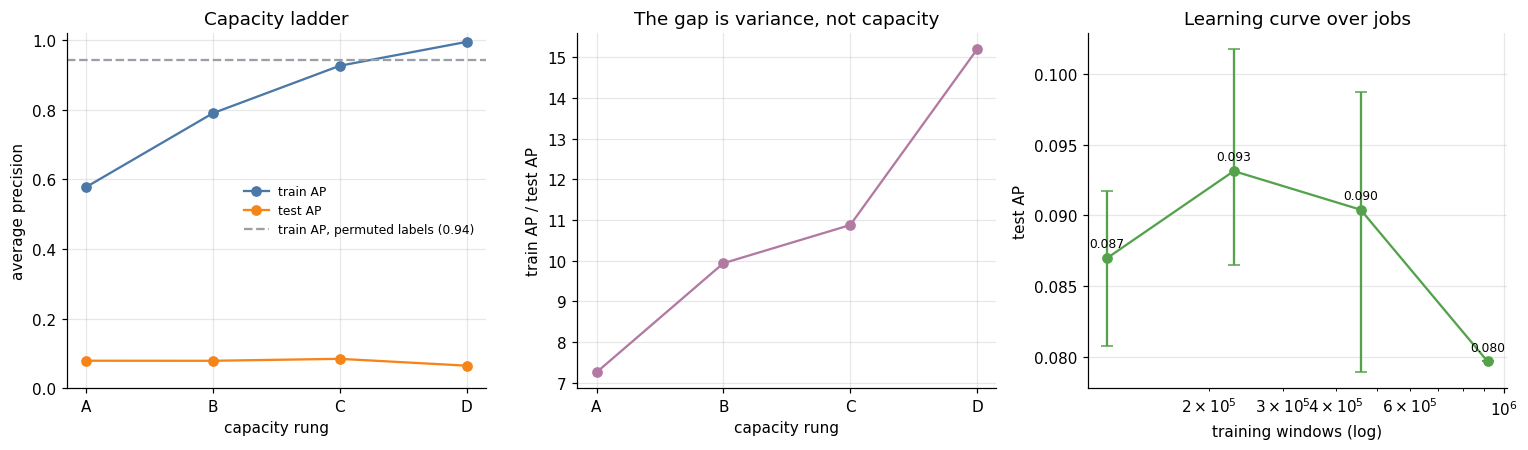

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))

x = np.arange(len(ladder))
ax[0].plot(x, ladder.train_ap, "o-", color="#4c78a8", label="train AP")
ax[0].plot(x, ladder.test_ap, "o-", color="#f58518", label="test AP")
ax[0].axhline(ap_tr_perm, color="#9aa0a6", ls="--", lw=1.5,
              label=f"train AP, permuted labels ({ap_tr_perm:.2f})")
ax[0].set_xticks(x, [r.split()[0] for r in ladder.rung])
ax[0].set(xlabel="capacity rung", ylabel="average precision",
          title="Capacity ladder", ylim=(0, 1.02))
ax[0].legend(frameon=False, fontsize=8)

ax[1].plot(x, ladder.gap, "o-", color="#b279a2")
ax[1].set_xticks(x, [r.split()[0] for r in ladder.rung])
ax[1].set(xlabel="capacity rung", ylabel="train AP / test AP",
          title="The gap is variance, not capacity")

ax[2].errorbar(curve.windows, curve.test_ap,
               yerr=[curve.test_ap - curve.ap_min, curve.ap_max - curve.test_ap],
               fmt="o-", color="#54a24b", capsize=4, lw=1.5)
ax[2].set(xscale="log", xlabel="training windows (log)", ylabel="test AP",
          title="Learning curve over jobs")
for _, r in curve.iterrows():
    ax[2].annotate(f"{r.test_ap:.3f}", (r.windows, r.test_ap),
                   textcoords="offset points", xytext=(0, 7), fontsize=8, ha="center")

plt.tight_layout(); save(fig, "01_headroom.png"); plt.show()

## Step 6 - Verdict

In [7]:
d1_rise = ladder.test_ap.max() / ladder.test_ap.iloc[0] - 1
facts["ladder_test_ap_rise"] = float(d1_rise)
facts["ladder_train_ap_rise"] = float(ladder.train_ap.max() / ladder.train_ap.iloc[0] - 1)
facts["max_gap"] = float(ladder.gap.max())

print(f"test AP across the ladder  : {ladder.test_ap.min():.4f} -> "
      f"{ladder.test_ap.max():.4f}  ({100*d1_rise:+.1f} %)")
print(f"train AP across the ladder : {ladder.train_ap.min():.4f} -> "
      f"{ladder.train_ap.max():.4f}")
print(f"widest train/test gap      : {ladder.gap.max():.1f}x")
print()
print(f"D1  capacity-limited : "
      f"{'YES - keep growing the model' if d1_rise > 0.25 else 'NO - growing the model is not the lever'}")
print()
# NOTE on reading "variance" here: windows inside one job are near-duplicates, so a
# large model can memorise a job's feature signature and its outcome. That inflates
# train AP without transferring to unseen jobs. The effective sample size is therefore
# closer to the number of training JOBS (10,265, of which ~1,700 are failing) than to
# the number of windows (915,508).
verdict = ("capacity" if d1_rise > 0.25 else
           "variance" if ladder.gap.max() > 3 else "signal")
facts["verdict"] = verdict
print(f"VERDICT: the binding limitation is **{verdict}**")
json.dump(facts, open(DATA / "facts_headroom.json", "w"), indent=1)
print(f"\n[{time.time()-t0:.0f}s total]")

test AP across the ladder  : 0.0655 -> 0.0852  (+6.9 %)
train AP across the ladder : 0.5782 -> 0.9950
widest train/test gap      : 15.2x

D1  capacity-limited : NO - growing the model is not the lever

VERDICT: the binding limitation is **variance**

[243s total]
